# BC_PPO

In [1]:
import sys, os, math, time, csv
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    !nvidia-smi  


sys.path.insert(0, ".")
import shooter  # registers Shooter-v0

print("Environment registered: Shooter-v0")

2026-05-10 20:05:40.394045: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using device: cuda
Sun May 10 20:05:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.52.01              Driver Version: 555.99         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
Environment registered: Shooter-v0


# LowLevelLeadAimAgent 

In [2]:

AI_SPEED     = 0.35
BULLET_SPEED = 2.5
TREE_R       = 2.5

def wrap_angle(angle: float) -> float:
    return (angle + math.pi) % (2.0 * math.pi) - math.pi

def extract_targets(obs):
    targets = []
    for slot in range(15):
        base = 6 + slot * 8
        if obs[base+6] > 0.5 and obs[base+7] > 0.5:
            x = float(obs[base]   * 100.0)
            z = float(obs[base+1] * 100.0)
            d = float(obs[base+2] * 141.0)
            y = float(obs[base+5] * 20.0)
            targets.append({"x":x, "y":y, "z":z, "dist":max(d,0.5)})
    return targets

def compute_intercept_aim(target, lead=1.30):
    x,y,z = target["x"], target["y"], target["z"]
    dist_xz = max(math.sqrt(x*x+z*z), 0.5)
    px,py,pz = x, y-2.3, z
    vx = -x/dist_xz * AI_SPEED
    vy = 0.0
    vz = -z/dist_xz * AI_SPEED
    a = vx*vx+vy*vy+vz*vz - BULLET_SPEED*BULLET_SPEED
    b = 2.0*(px*vx+py*vy+pz*vz)
    c = px*px+py*py+pz*pz
    disc = b*b-4*a*c
    if disc >= 0 and abs(a)>1e-8:
        root = math.sqrt(disc)
        t1 = (-b-root)/(2*a)
        t2 = (-b+root)/(2*a)
        valid = [t for t in (t1,t2) if 0<t<120]
        T = min(valid) if valid else dist_xz/BULLET_SPEED
    else:
        T = dist_xz/BULLET_SPEED
    T = max(0.0, min(T*lead, 120.0))
    aim_x = px + vx*T
    aim_y = py + vy*T
    aim_z = pz + vz*T
    req_yaw = math.atan2(aim_z, aim_x)
    req_pitch = math.atan2(aim_y, max(math.sqrt(aim_x**2+aim_z**2),0.5))
    return req_yaw, req_pitch

class LowLevelLeadAimAgent:
    def __init__(self):
        self.last_fire_tick = -9999
        self.fire_cooldown = 8
        self.max_fire_dist = 85.0
        self.min_fire_dist = 8.0
        self.max_bullets   = 1
        self.lead_scale    = 1.30

    def fire_tolerances(self, dist):
        yaw_tol   = max(0.065, min(0.16, 3.0/max(dist,1)))
        pitch_tol = max(0.045, min(0.14, 2.5/max(dist,1)))
        return yaw_tol, pitch_tol

    def choose_nearest(self, obs):
        targets = extract_targets(obs)
        if not targets: return None
        practical = [t for t in targets if t["dist"]>=self.min_fire_dist]
        return min(practical if practical else targets, key=lambda t: t["dist"])

    def action(self, obs, info):
        target = self.choose_nearest(obs)
        if target is None:
            return 0  # do_nothing
        cur_yaw   = float(obs[3]*math.pi)
        cur_pitch = float(obs[4]*0.9)
        req_yaw, req_pitch = compute_intercept_aim(target, self.lead_scale)
        yaw_err = wrap_angle(req_yaw - cur_yaw)
        pitch_err = req_pitch - cur_pitch
        dist = float(target["dist"])
        yt, pt = self.fire_tolerances(dist)
        aligned = abs(yaw_err)<=yt and abs(pitch_err)<=pt
        tick = int(info.get("tick",0))
        bullets = int(info.get("bullets_in_flight",0))
        cd = (tick - self.last_fire_tick) >= self.fire_cooldown
        dist_ok = self.min_fire_dist <= dist <= self.max_fire_dist
        bullet_ok = bullets <= self.max_bullets
        if aligned and cd and dist_ok and bullet_ok:
            self.last_fire_tick = tick
            return 1  # fire
       
        if abs(yaw_err) > 0.04:
            return 2 if yaw_err > 0 else 3
        if abs(pitch_err) > 0.014:
            return 4 if pitch_err > 0 else 5
        return 0  # do_nothing

#  Generate dataset from expert

In [3]:

def generate_dataset(num_episodes=300, seed_offset=0):
    env = gym.make("Shooter-v0", render_mode=None)
    data_obs = []
    data_act = []
    for ep in range(num_episodes):
        seed = seed_offset + ep
        obs, info = env.reset(seed=seed)
        agent = LowLevelLeadAimAgent()
        done = False
        while not done:
            act = agent.action(obs, info)
            data_obs.append(obs)
            data_act.append(act)
            obs, reward, terminated, truncated, info = env.step(act)
            done = terminated or truncated
        if (ep+1) % 50 == 0:
            print(f"  Episode {ep+1}/{num_episodes} done")
    env.close()
    return np.array(data_obs, dtype=np.float32), np.array(data_act, dtype=np.int64)

print("Generating dataset...")
obs_data, act_data = generate_dataset(num_episodes=300, seed_offset=1000)
print(f"Dataset size: {len(obs_data)} samples")

Generating dataset...
  Episode 50/300 done
  Episode 100/300 done
  Episode 150/300 done
  Episode 200/300 done
  Episode 250/300 done
  Episode 300/300 done
Dataset size: 511429 samples



#  Train Behavioral Cloning (BC) model

In [4]:
HIDDEN = [256, 128]
class BCPolicy(nn.Module):
    def __init__(self, obs_dim=169, act_dim=6):
        super().__init__()
        self.feature_net = nn.Sequential(
            nn.Linear(obs_dim, HIDDEN[0]), nn.ReLU(),
            nn.Linear(HIDDEN[0], HIDDEN[1]), nn.ReLU()
        )
        self.head = nn.Linear(HIDDEN[1], act_dim)

    def forward(self, x):
        feats = self.feature_net(x)
        return self.head(feats)


dataset = TensorDataset(torch.tensor(obs_data), torch.tensor(act_data))
loader  = DataLoader(dataset, batch_size=512, shuffle=True)

bc_model = BCPolicy().to(device)
optimizer = torch.optim.Adam(bc_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 30  
print("Training BC...")
for epoch in range(epochs):
    total_loss = 0.0
    correct = 0
    total = 0
    for batch_obs, batch_act in loader:
        batch_obs = batch_obs.to(device)
        batch_act = batch_act.to(device)
        optimizer.zero_grad()
        logits = bc_model(batch_obs)
        loss = criterion(logits, batch_act)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch_obs)
        correct += (logits.argmax(dim=1) == batch_act).sum().item()
        total += len(batch_obs)
    acc = correct / total
    print(f"Epoch {epoch+1:2d} | Loss: {total_loss/total:.4f} | Acc: {acc:.3f}")


torch.save({
    'feature_net': bc_model.feature_net.state_dict(),
    'head': bc_model.head.state_dict()
}, "bc_policy_weights.pth")
print("BC weights saved to bc_policy_weights.pth")

Training BC...
Epoch  1 | Loss: 1.1388 | Acc: 0.580
Epoch  2 | Loss: 0.7384 | Acc: 0.757
Epoch  3 | Loss: 0.6256 | Acc: 0.787
Epoch  4 | Loss: 0.5551 | Acc: 0.803
Epoch  5 | Loss: 0.5007 | Acc: 0.818
Epoch  6 | Loss: 0.4582 | Acc: 0.832
Epoch  7 | Loss: 0.4244 | Acc: 0.844
Epoch  8 | Loss: 0.4061 | Acc: 0.851
Epoch  9 | Loss: 0.3753 | Acc: 0.864
Epoch 10 | Loss: 0.3673 | Acc: 0.866
Epoch 11 | Loss: 0.3420 | Acc: 0.876
Epoch 12 | Loss: 0.3308 | Acc: 0.880
Epoch 13 | Loss: 0.3159 | Acc: 0.885
Epoch 14 | Loss: 0.3019 | Acc: 0.890
Epoch 15 | Loss: 0.2907 | Acc: 0.895
Epoch 16 | Loss: 0.2825 | Acc: 0.897
Epoch 17 | Loss: 0.2669 | Acc: 0.904
Epoch 18 | Loss: 0.2634 | Acc: 0.904
Epoch 19 | Loss: 0.2585 | Acc: 0.907
Epoch 20 | Loss: 0.2512 | Acc: 0.909
Epoch 21 | Loss: 0.2447 | Acc: 0.912
Epoch 22 | Loss: 0.2362 | Acc: 0.915
Epoch 23 | Loss: 0.2368 | Acc: 0.915
Epoch 24 | Loss: 0.2321 | Acc: 0.916
Epoch 25 | Loss: 0.2330 | Acc: 0.916
Epoch 26 | Loss: 0.2254 | Acc: 0.919
Epoch 27 | Loss: 0.2212


# Create vertorized env & Reward Shaping


In [6]:

from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.env_util import make_vec_env


class SimpleRewardWrapper(gym.Wrapper):
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.prev_score = info["hunterScore"]
        return obs, info
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        score_delta = info["hunterScore"] - self.prev_score
        self.prev_score = info["hunterScore"]
        shaped = reward
        if score_delta > 0:
            shaped += score_delta * 5.0   
       
        return obs, shaped, terminated, truncated, info


vec_env = make_vec_env(
    lambda: SimpleRewardWrapper(gym.make("Shooter-v0", render_mode=None)),
    n_envs=4
)


policy_kwargs = dict(net_arch=dict(pi=HIDDEN, vf=[256,128]))
ppo_model = PPO(
    "MlpPolicy",
    vec_env,                       
    policy_kwargs=policy_kwargs,
    learning_rate=1e-4,
    n_steps=2048,
    batch_size=128,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    verbose=0,
    device=device                
)


checkpoint = torch.load("bc_policy_weights.pth", map_location=device)
policy = ppo_model.policy
policy.mlp_extractor.policy_net.load_state_dict(checkpoint['feature_net'])
policy.action_net.load_state_dict(checkpoint['head'])
print("BC weights loaded into PPO policy.")


class SimpleCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.ep_count = 0
    def _on_step(self):
        if self.locals.get("dones") is not None:
            for done in self.locals["dones"]:
                if done:
                    self.ep_count += 1
        return True


print("Starting fine-tuning (PPO)...")
ppo_model.learn(total_timesteps=1_000_000, callback=SimpleCallback(), progress_bar=True)
ppo_model.save("ppo_v9_finetuned")
print("Saved ppo_v9_finetuned.zip")

Output()

BC weights loaded into PPO policy.
Starting fine-tuning (PPO)...


Saved ppo_v9_finetuned.zip


# Test final

In [7]:
def test_model(model_path, episodes=5):
    model = PPO.load(model_path)
    env = gym.make("Shooter-v0", render_mode=None)
    results = []
    for ep in range(episodes):
        obs, info = env.reset()
        total_reward = 0.0
        steps = 0
        kills = 0
        prev_score = info["hunterScore"]
        while True:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1
            if info["hunterScore"] - prev_score > 0:
                kills += 1
            prev_score = info["hunterScore"]
            if terminated or truncated:
                break
        results.append((total_reward, info["hunterScore"], kills, steps))
        print(f"Ep {ep+1}: Reward={total_reward:8.1f} Score={info['hunterScore']:5.0f} Kills={kills:3d} Steps={steps:4d}")
    env.close()
    scores = [r[1] for r in results]
    print(f"\nMean Score: {np.mean(scores):.1f}, Max: {max(scores)}")

test_model("ppo_v9_finetuned", episodes=5)

Ep 1: Reward=   -98.3 Score=   12 Kills=  1 Steps= 229
Ep 2: Reward=  -142.1 Score=  -32 Kills=  1 Steps= 229
Ep 3: Reward=  -103.0 Score=    8 Kills=  2 Steps= 232
Ep 4: Reward=  -102.3 Score=    8 Kills=  1 Steps= 229
Ep 5: Reward=   -96.3 Score=   14 Kills=  1 Steps= 229

Mean Score: 2.0, Max: 14



# Resume fine-tune PPO with detailed callback


In [8]:
import time
from stable_baselines3.common.callbacks import BaseCallback


class ShooterRewardWrapperV9(gym.Wrapper):
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.prev_score = info["hunterScore"]
        self._kills = 0
        return obs, info
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        shaped = reward
        score_delta = info["hunterScore"] - self.prev_score
        self.prev_score = info["hunterScore"]
        if score_delta > 0:
            shaped += score_delta * 4.0    
            self._kills += 1
        
        err = _calc_aim_error(obs)  
        if err is not None:
            shaped += 2.0 * math.exp(-err**2 / 0.1)
        info["kills"] = self._kills
        return obs, shaped, terminated, truncated, info


def _calc_aim_error(obs):
    best_dist = 1e9
    best_x = best_y = best_z = None
    base = 6
    for i in range(15):
        j = base + i * 8
        if obs[j + 6] > 0.5:
            x = obs[j] * 100.0
            z = obs[j + 1] * 100.0
            y = obs[j + 5] * 20.0
            dist = math.sqrt(x * x + z * z)
            if dist < best_dist:
                best_dist = dist
                best_x, best_y, best_z = x, y, z
    if best_x is None: return None
    cur_yaw = obs[3] * math.pi
    cur_pitch = obs[4] * 0.9
    ideal_yaw = math.atan2(best_z, best_x)
    xz_dist = max(math.sqrt(best_x**2 + best_z**2), 0.5)
    ideal_pitch = math.atan2(best_y - 2.3, xz_dist)
    yaw_err = abs(wrap_angle(ideal_yaw - cur_yaw))
    pitch_err = abs(ideal_pitch - cur_pitch)
    return yaw_err + pitch_err


class DetailedLogCallback(BaseCallback):
    def __init__(self, log_every=100):
        super().__init__()
        self.log_every = log_every
        self.ep_count = 0
        self.cur_rewards = {}
        self.ep_rewards = []
        self.ep_kills = []
        self.ep_scores = []
        self.start_time = time.time()
    def _on_step(self):
        infos = self.locals.get("infos", [{}] * len(self.locals["dones"]))
        for i, done in enumerate(self.locals["dones"]):
            self.cur_rewards[i] = self.cur_rewards.get(i, 0) + self.locals["rewards"][i]
            if done:
                self.ep_count += 1
                self.ep_rewards.append(self.cur_rewards[i])
                self.ep_kills.append(infos[i].get("kills", 0))
                self.ep_scores.append(infos[i].get("hunterScore", 0))
                self.cur_rewards[i] = 0
                if self.ep_count % self.log_every == 0:
                    recent_r = self.ep_rewards[-self.log_every:]
                    recent_k = self.ep_kills[-self.log_every:]
                    recent_s = self.ep_scores[-self.log_every:]
                    elapsed = time.time() - self.start_time
                    print(f"Ep {self.ep_count:5d} | "
                          f"Mean: {np.mean(recent_r):7.2f} | "
                          f"Max: {np.max(recent_r):7.2f} | "
                          f"Min: {np.min(recent_r):7.2f} | "
                          f"Kill: {int(np.sum(recent_k)):4d} | "
                          f"Score: {np.mean(recent_s):6.1f} | "
                          f"Step {self.num_timesteps:7d} | "
                          f"Time: {elapsed/60:6.1f}m")
        return True


os.makedirs("models/PPO_v9", exist_ok=True)
vec_env2 = make_vec_env(lambda: ShooterRewardWrapperV9(gym.make("Shooter-v0", render_mode=None)), n_envs=4)


model = PPO.load("ppo_v9_finetuned", env=vec_env2, device=device)

print("Resume fine-tuning (2M more steps) with detailed logging...")
model.learn(total_timesteps=2_000_000, callback=DetailedLogCallback(log_every=100), progress_bar=True)
model.save("models/PPO_v9/ppo_v9_final")
print("Saved to models/PPO_v9/ppo_v9_final.zip")

Output()

Resume fine-tuning (2M more steps) with detailed logging...


Ep   100 | Mean:   44.86 | Max:  216.42 | Min: -137.48 | Kill:  133 | Score:    3.0 | Step   22988 | Time:    0.5m

Ep   200 | Mean:   86.72 | Max:  295.82 | Min: -115.16 | Kill:  148 | Score:    4.7 | Step   46024 | Time:    1.1m

Ep   300 | Mean:  111.59 | Max:  347.65 | Min: -121.42 | Kill:  147 | Score:    4.6 | Step   69164 | Time:    1.7m

...

Ep  2800 | Mean: 2765.39 | Max: 8881.95 | Min: -104.20 | Kill: 1948 | Score:  224.7 | Step 1612856 | Time:   42.2m

Ep  2900 | Mean: 2780.98 | Max: 9309.24 | Min:  -45.58 | Kill: 1944 | Score:  225.3 | Step 1724060 | Time:   45.2m

Ep  3000 | Mean: 2764.54 | Max: 10604.24 | Min:  112.99 | Kill: 1943 | Score:  224.9 | Step 1834640 | Time:   48.1m

Ep  3100 | Mean: 3174.41 | Max: 11807.16 | Min:   71.46 | Kill: 2225 | Score:  258.7 | Step 1958424 | Time:   51.4m

Saved to models/PPO_v9/ppo_v9_final.zip


# Testing 30 episodes 

In [9]:

def test_model_full(model_path, episodes=30):
    model = PPO.load(model_path)
    env = gym.make("Shooter-v0", render_mode=None)
    results, scores, kills_list, times_list = [], [], [], []
    for ep in range(episodes):
        obs, info = env.reset()
        total_reward, steps, ep_kills = 0, 0, 0
        prev_score = info["hunterScore"]
        ep_start = time.time()
        while True:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1
            if info["hunterScore"] - prev_score > 0:
                ep_kills += 1
            prev_score = info["hunterScore"]
            if terminated or truncated:
                break
        ep_time = time.time() - ep_start
        results.append(total_reward)
        scores.append(info["hunterScore"])
        kills_list.append(ep_kills)
        times_list.append(ep_time)
        print(f"Ep {ep+1:2d} | Reward: {total_reward:8.1f} | Score: {info['hunterScore']:5d} | Kill: {ep_kills:3d} | Steps: {steps:4d} | Time: {ep_time:.1f}s")
    env.close()
    print(f"\n--- Final Summary ---")
    print(f"Mean Reward : {np.mean(results):8.2f} +/- {np.std(results):.2f}")
    print(f"Max Reward  : {np.max(results):8.2f}")
    print(f"Mean Score  : {np.mean(scores):8.2f}")
    print(f"Max Score   : {int(np.max(scores)):8d}")
    print(f"Mean Kill   : {np.mean(kills_list):8.2f}")
    print(f"Total Kill  : {int(np.sum(kills_list)):8d}  (over {episodes} eps)")
    print(f"Mean Time   : {np.mean(times_list):8.2f}s per episode")
    print(f"Success Rate: {np.sum(np.array(scores) > 0) / len(scores) * 100:.1f}%")

test_model_full("models/PPO_v9/ppo_v9_final", episodes=30)

Ep  1 | Reward:    -80.4 | Score:    30 | Kill:   3 | Steps:  230 | Time: 0.4s
Ep  2 | Reward:    578.1 | Score:   750 | Kill:  59 | Steps: 2936 | Time: 3.4s
Ep  3 | Reward:   -114.3 | Score:    -4 | Kill:   2 | Steps:  229 | Time: 0.3s
Ep  4 | Reward:    114.7 | Score:   248 | Kill:  23 | Steps: 1428 | Time: 1.6s
Ep  5 | Reward:    -26.5 | Score:   108 | Kill:  14 | Steps:  988 | Time: 1.2s
Ep  6 | Reward:   -113.7 | Score:    -4 | Kill:   2 | Steps:  230 | Time: 0.3s
Ep  7 | Reward:   -134.8 | Score:   -24 | Kill:   2 | Steps:  231 | Time: 0.2s
Ep  8 | Reward:    -84.3 | Score:    26 | Kill:   2 | Steps:  229 | Time: 0.3s
Ep  9 | Reward:   -111.7 | Score:    -2 | Kill:   2 | Steps:  232 | Time: 0.3s
Ep 10 | Reward:    432.7 | Score:   576 | Kill:  48 | Steps: 2628 | Time: 3.1s
Ep 11 | Reward:   -144.3 | Score:   -34 | Kill:   2 | Steps:  229 | Time: 0.3s
Ep 12 | Reward:   -116.6 | Score:    -6 | Kill:   3 | Steps:  234 | Time: 0.3s
Ep 13 | Reward:      3.6 | Score:   114 | Kill:  11 

In [11]:
import gymnasium as gym
from stable_baselines3 import PPO
import shooter

model = PPO.load("models/PPO_v9/ppo_v9_final")
env = gym.make("Shooter-v0", render_mode="human")

episodes = 5
for ep in range(episodes):
    obs, info = env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(int(action))
        done = terminated or truncated
env.close()
print("Done:", episodes, "episodes")

/home/paradorn00/miniconda3/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Done: 5 episodes


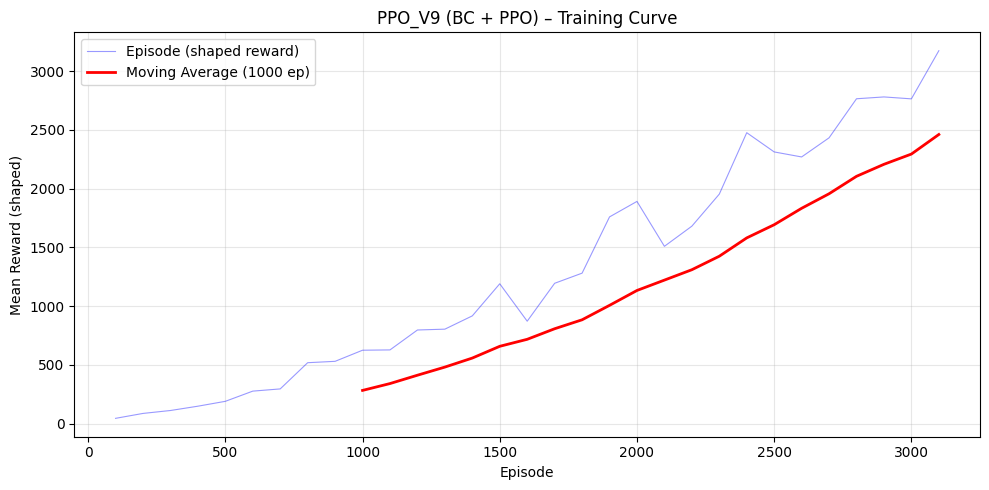

In [3]:
import re
import matplotlib.pyplot as plt
import numpy as np

raw_text = """
Ep   100 | Mean:   44.86 | Max:  216.42 | Min: -137.48 | Kill:  133 | Score:    3.0 | Step   22988 | Time:    0.5m
Ep   200 | Mean:   86.72 | Max:  295.82 | Min: -115.16 | Kill:  148 | Score:    4.7 | Step   46024 | Time:    1.1m
Ep   300 | Mean:  111.59 | Max:  347.65 | Min: -121.42 | Kill:  147 | Score:    4.6 | Step   69164 | Time:    1.7m
Ep   400 | Mean:  148.26 | Max:  375.64 | Min:  -83.78 | Kill:  162 | Score:    9.6 | Step   92192 | Time:    2.5m
Ep   500 | Mean:  189.71 | Max: 1444.64 | Min: -107.10 | Kill:  180 | Score:   15.9 | Step  116020 | Time:    3.3m
Ep   600 | Mean:  276.53 | Max: 3157.54 | Min:  -56.69 | Kill:  233 | Score:   22.8 | Step  142932 | Time:    4.2m
Ep   700 | Mean:  295.42 | Max: 1706.56 | Min:  -92.85 | Kill:  253 | Score:   25.4 | Step  168960 | Time:    5.0m
Ep   800 | Mean:  518.46 | Max: 3193.79 | Min:  -80.14 | Kill:  407 | Score:   46.3 | Step  204460 | Time:    6.1m
Ep   900 | Mean:  530.18 | Max: 3645.20 | Min:   17.33 | Kill:  417 | Score:   42.4 | Step  240948 | Time:    7.1m
Ep  1000 | Mean:  624.77 | Max: 3467.72 | Min:   29.27 | Kill:  479 | Score:   52.5 | Step  281496 | Time:    8.2m
Ep  1100 | Mean:  627.39 | Max: 3402.40 | Min:    2.41 | Kill:  474 | Score:   50.3 | Step  322740 | Time:    9.2m
Ep  1200 | Mean:  796.91 | Max: 3950.16 | Min:   29.99 | Kill:  586 | Score:   65.2 | Step  369052 | Time:   10.5m
Ep  1300 | Mean:  804.08 | Max: 4205.80 | Min:    9.53 | Kill:  589 | Score:   64.7 | Step  417112 | Time:   11.8m
Ep  1400 | Mean:  917.13 | Max: 6610.85 | Min:  -61.82 | Kill:  663 | Score:   75.6 | Step  468432 | Time:   13.2m
Ep  1500 | Mean: 1190.37 | Max: 6290.97 | Min:   55.54 | Kill:  844 | Score:   94.9 | Step  531028 | Time:   14.6m
Ep  1600 | Mean:  871.80 | Max: 6679.52 | Min:  -43.38 | Kill:  631 | Score:   71.1 | Step  581700 | Time:   15.9m
Ep  1700 | Mean: 1194.58 | Max: 5290.73 | Min:   26.89 | Kill:  839 | Score:   99.7 | Step  646060 | Time:   17.3m
Ep  1800 | Mean: 1280.81 | Max: 6574.33 | Min:  -43.62 | Kill:  896 | Score:  106.5 | Step  709992 | Time:   19.1m
Ep  1900 | Mean: 1759.62 | Max: 7281.45 | Min:  -71.96 | Kill: 1198 | Score:  147.8 | Step  789860 | Time:   21.1m
Ep  2000 | Mean: 1891.53 | Max: 7631.62 | Min:   38.83 | Kill: 1311 | Score:  147.7 | Step  873992 | Time:   23.5m
Ep  2100 | Mean: 1509.27 | Max: 6986.63 | Min:   65.29 | Kill: 1077 | Score:  118.3 | Step  943488 | Time:   25.4m
Ep  2200 | Mean: 1680.78 | Max: 9935.37 | Min:   40.99 | Kill: 1181 | Score:  123.7 | Step 1023596 | Time:   27.3m
Ep  2300 | Mean: 1953.47 | Max: 7902.61 | Min:   20.16 | Kill: 1378 | Score:  156.0 | Step 1108224 | Time:   29.4m
Ep  2400 | Mean: 2476.57 | Max: 9200.23 | Min:  -13.02 | Kill: 1726 | Score:  204.1 | Step 1210804 | Time:   32.0m
Ep  2500 | Mean: 2312.80 | Max: 8317.78 | Min:   39.91 | Kill: 1607 | Score:  191.8 | Step 1306860 | Time:   34.4m
Ep  2600 | Mean: 2270.05 | Max: 10240.89 | Min:  119.58 | Kill: 1588 | Score:  184.6 | Step 1406832 | Time:   37.0m
Ep  2700 | Mean: 2432.96 | Max: 9534.70 | Min:   63.83 | Kill: 1698 | Score:  196.8 | Step 1504968 | Time:   39.5m
Ep  2800 | Mean: 2765.39 | Max: 8881.95 | Min: -104.20 | Kill: 1948 | Score:  224.7 | Step 1612856 | Time:   42.2m
Ep  2900 | Mean: 2780.98 | Max: 9309.24 | Min:  -45.58 | Kill: 1944 | Score:  225.3 | Step 1724060 | Time:   45.2m
Ep  3000 | Mean: 2764.54 | Max: 10604.24 | Min:  112.99 | Kill: 1943 | Score:  224.9 | Step 1834640 | Time:   48.1m
Ep  3100 | Mean: 3174.41 | Max: 11807.16 | Min:   71.46 | Kill: 2225 | Score:  258.7 | Step 1958424 | Time:   51.4m
"""

pattern = r"Ep\s+(\d+)\s+\|\s+Mean:\s+([-\d.]+)"
matches = re.findall(pattern, raw_text)

episodes = [int(m[0]) for m in matches]
mean_rewards = [float(m[1]) for m in matches]

episodes = np.array(episodes)
mean_rewards = np.array(mean_rewards)

plt.figure(figsize=(10, 5))
plt.plot(episodes, mean_rewards, alpha=0.4, linewidth=0.8, color='blue', label='Episode (shaped reward)')

window = 10
if len(mean_rewards) >= window:
    ma = np.convolve(mean_rewards, np.ones(window)/window, mode='valid')
    plt.plot(episodes[window-1:], ma, color='red', linewidth=2, label=f'Moving Average ({window*100} ep)')

plt.xlabel('Episode')
plt.ylabel('Mean Reward (shaped)')
plt.title('PPO_V9 (BC + PPO) – Training Curve')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('ppo_v9_training_curve.png', dpi=150)
plt.show()

In [3]:
# =============================================================
# Cell: PPO_V9 Evaluation (10 episodes + TensorBoard + Video)
# =============================================================
import time
import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO
from torch.utils.tensorboard import SummaryWriter
from gymnasium.wrappers import RecordVideo

MODEL_PATH = "models/PPO_v9/ppo_v9_final"
LOG_DIR    = "runs/PPO_v9_eval"
VIDEO_DIR  = "videos/PPO_v9_best"
NUM_EPS    = 10

model = PPO.load(MODEL_PATH)
writer = SummaryWriter(LOG_DIR)

# Phase 1 – evaluate with fixed seeds, store seed for each episode
results = []          # (total_reward, final_score, kills, steps, seed)
print(f"Evaluating PPO_V9 – {NUM_EPS} episodes …\n")
for ep in range(NUM_EPS):
    ep_seed = 4000 + ep          # fixed seed, different range from V5 to avoid collision
    env = gym.make("Shooter-v0", render_mode=None)
    obs, info = env.reset(seed=ep_seed)
    total_reward, ep_kills = 0.0, 0
    prev_score = info["hunterScore"]

    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        score_delta = info["hunterScore"] - prev_score
        if score_delta > 0:
            ep_kills += 1
        prev_score = info["hunterScore"]
        if terminated or truncated:
            break
    env.close()

    final_score = info["hunterScore"]
    steps = info["tick"]
    results.append((total_reward, final_score, ep_kills, steps, ep_seed))

    # Log each episode to TensorBoard
    writer.add_scalar("Episode/Reward", total_reward, ep)
    writer.add_scalar("Episode/Score",  final_score,  ep)
    writer.add_scalar("Episode/Kills",  ep_kills,     ep)
    writer.add_scalar("Episode/Steps",  steps,        ep)

# Convert to numpy arrays for analysis
arr_rewards = np.array([r[0] for r in results])
arr_scores  = np.array([r[1] for r in results])
arr_kills   = np.array([r[2] for r in results])
arr_steps   = np.array([r[3] for r in results])

best_reward_idx = np.argmax(arr_rewards)
best_score_idx  = np.argmax(arr_scores)
best_kill_idx   = np.argmax(arr_kills)

# Print summary table
print("─" * 60)
print(f"{'Ep':>4s} | {'Reward':>10s} | {'Score':>6s} | {'Kills':>5s} | {'Steps':>5s} | {'Seed':>5s}")
print("─" * 60)
for i in range(NUM_EPS):
    print(f"{i+1:4d} | {arr_rewards[i]:10.2f} | {arr_scores[i]:6d} | {arr_kills[i]:5d} | {arr_steps[i]:5d} | {results[i][4]:5d}")
print("─" * 60)
print(f"Best Reward : episode {best_reward_idx+1:2d}  with reward = {arr_rewards[best_reward_idx]:.2f}  (seed {results[best_reward_idx][4]})")
print(f"Best Score  : episode {best_score_idx+1:2d}  with score  = {arr_scores[best_score_idx]}  (seed {results[best_score_idx][4]})")
print(f"Best Kills  : episode {best_kill_idx+1:2d}  with kills  = {arr_kills[best_kill_idx]}  (seed {results[best_kill_idx][4]})")
print("─" * 60)

# Log overall summary scalars
writer.add_scalar("Summary/Mean_Reward", np.mean(arr_rewards))
writer.add_scalar("Summary/Std_Reward",  np.std(arr_rewards))
writer.add_scalar("Summary/Mean_Score",  np.mean(arr_scores))
writer.add_scalar("Summary/Mean_Kills",  np.mean(arr_kills))

# Phase 2 – record the exact episode with the BEST SCORE
chosen_ep = best_score_idx               # best score, not reward
best_seed = results[chosen_ep][4]
print(f"\nRecording episode {chosen_ep+1} (best score) with seed={best_seed} (score will be {arr_scores[chosen_ep]}) …")

# Create a fresh environment with the RecordVideo wrapper
env = gym.make("Shooter-v0", render_mode="rgb_array")
env = RecordVideo(
    env, VIDEO_DIR,
    episode_trigger=lambda ep_id: ep_id == 0   # record the very first episode
)
obs, info = env.reset(seed=best_seed)          # same seed as Phase 1 ⇒ identical episode

while True:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break
env.close()

writer.close()
print(f"\nVideo saved in '{VIDEO_DIR}'.")
print(f"Run `tensorboard --logdir runs` to view logs.")

/home/paradorn00/miniconda3/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Evaluating PPO_V9 – 10 episodes …

────────────────────────────────────────────────────────────
  Ep |     Reward |  Score | Kills | Steps |  Seed
────────────────────────────────────────────────────────────
   1 |    -100.25 |     10 |     2 |   231 |  4000
   2 |     -88.28 |     22 |     2 |   229 |  4001
   3 |     269.71 |    382 |    32 |  1764 |  4002
   4 |     479.85 |    604 |    50 |  2628 |  4003
   5 |      32.36 |    146 |    21 |  1383 |  4004
   6 |     -86.28 |     24 |     2 |   229 |  4005
   7 |      64.11 |    182 |    23 |  1461 |  4006
   8 |    -116.28 |     -2 |     3 |   240 |  4007
   9 |     -96.55 |     16 |     3 |   240 |  4008
  10 |     -70.23 |     40 |     3 |   230 |  4009
────────────────────────────────────────────────────────────
Best Reward : episode  4  with reward = 479.85  (seed 4003)
Best Score  : episode  4  with score  = 604  (seed 4003)
Best Kills  : episode  4  with kills  = 50  (seed 4003)
────────────────────────────────────────────────

/home/paradorn00/miniconda3/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /mnt/c/Users/lenovo/Desktop/FOR AIT HOMEWORK/2_Y1 SEM 2/Deep learning/Final Project/project/videos/PPO_v9_best folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(



Video saved in 'videos/PPO_v9_best'.
Run `tensorboard --logdir runs` to view logs.


In [4]:
!tensorboard --logdir runs

/home/paradorn00/miniconda3/lib/python3.13/site-packages/tensorboard/default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.20.0 at http://localhost:6006/ (Press CTRL+C to quit)
^C
